In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

In [3]:
energy = pd.read_excel('data/ENB2012_data.xlsx', names='RelativeCompactness SurfaceArea WallArea RoofArea OverallHeight Orientation GlazingArea GlazingAreaDistribution HeatingLoad CoolingLoad'.split())

In [4]:
energy.head()

,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,HeatingLoad,CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [5]:
energy.isnull().sum()

RelativeCompactness        0
SurfaceArea                0
WallArea                   0
RoofArea                   0
OverallHeight              0
Orientation                0
GlazingArea                0
GlazingAreaDistribution    0
HeatingLoad                0
CoolingLoad                0
dtype: int64

In [6]:
energy.describe()

,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,HeatingLoad,CoolingLoad
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [7]:
sns.set_theme(style='white',font_scale=1.5,palette='bright')

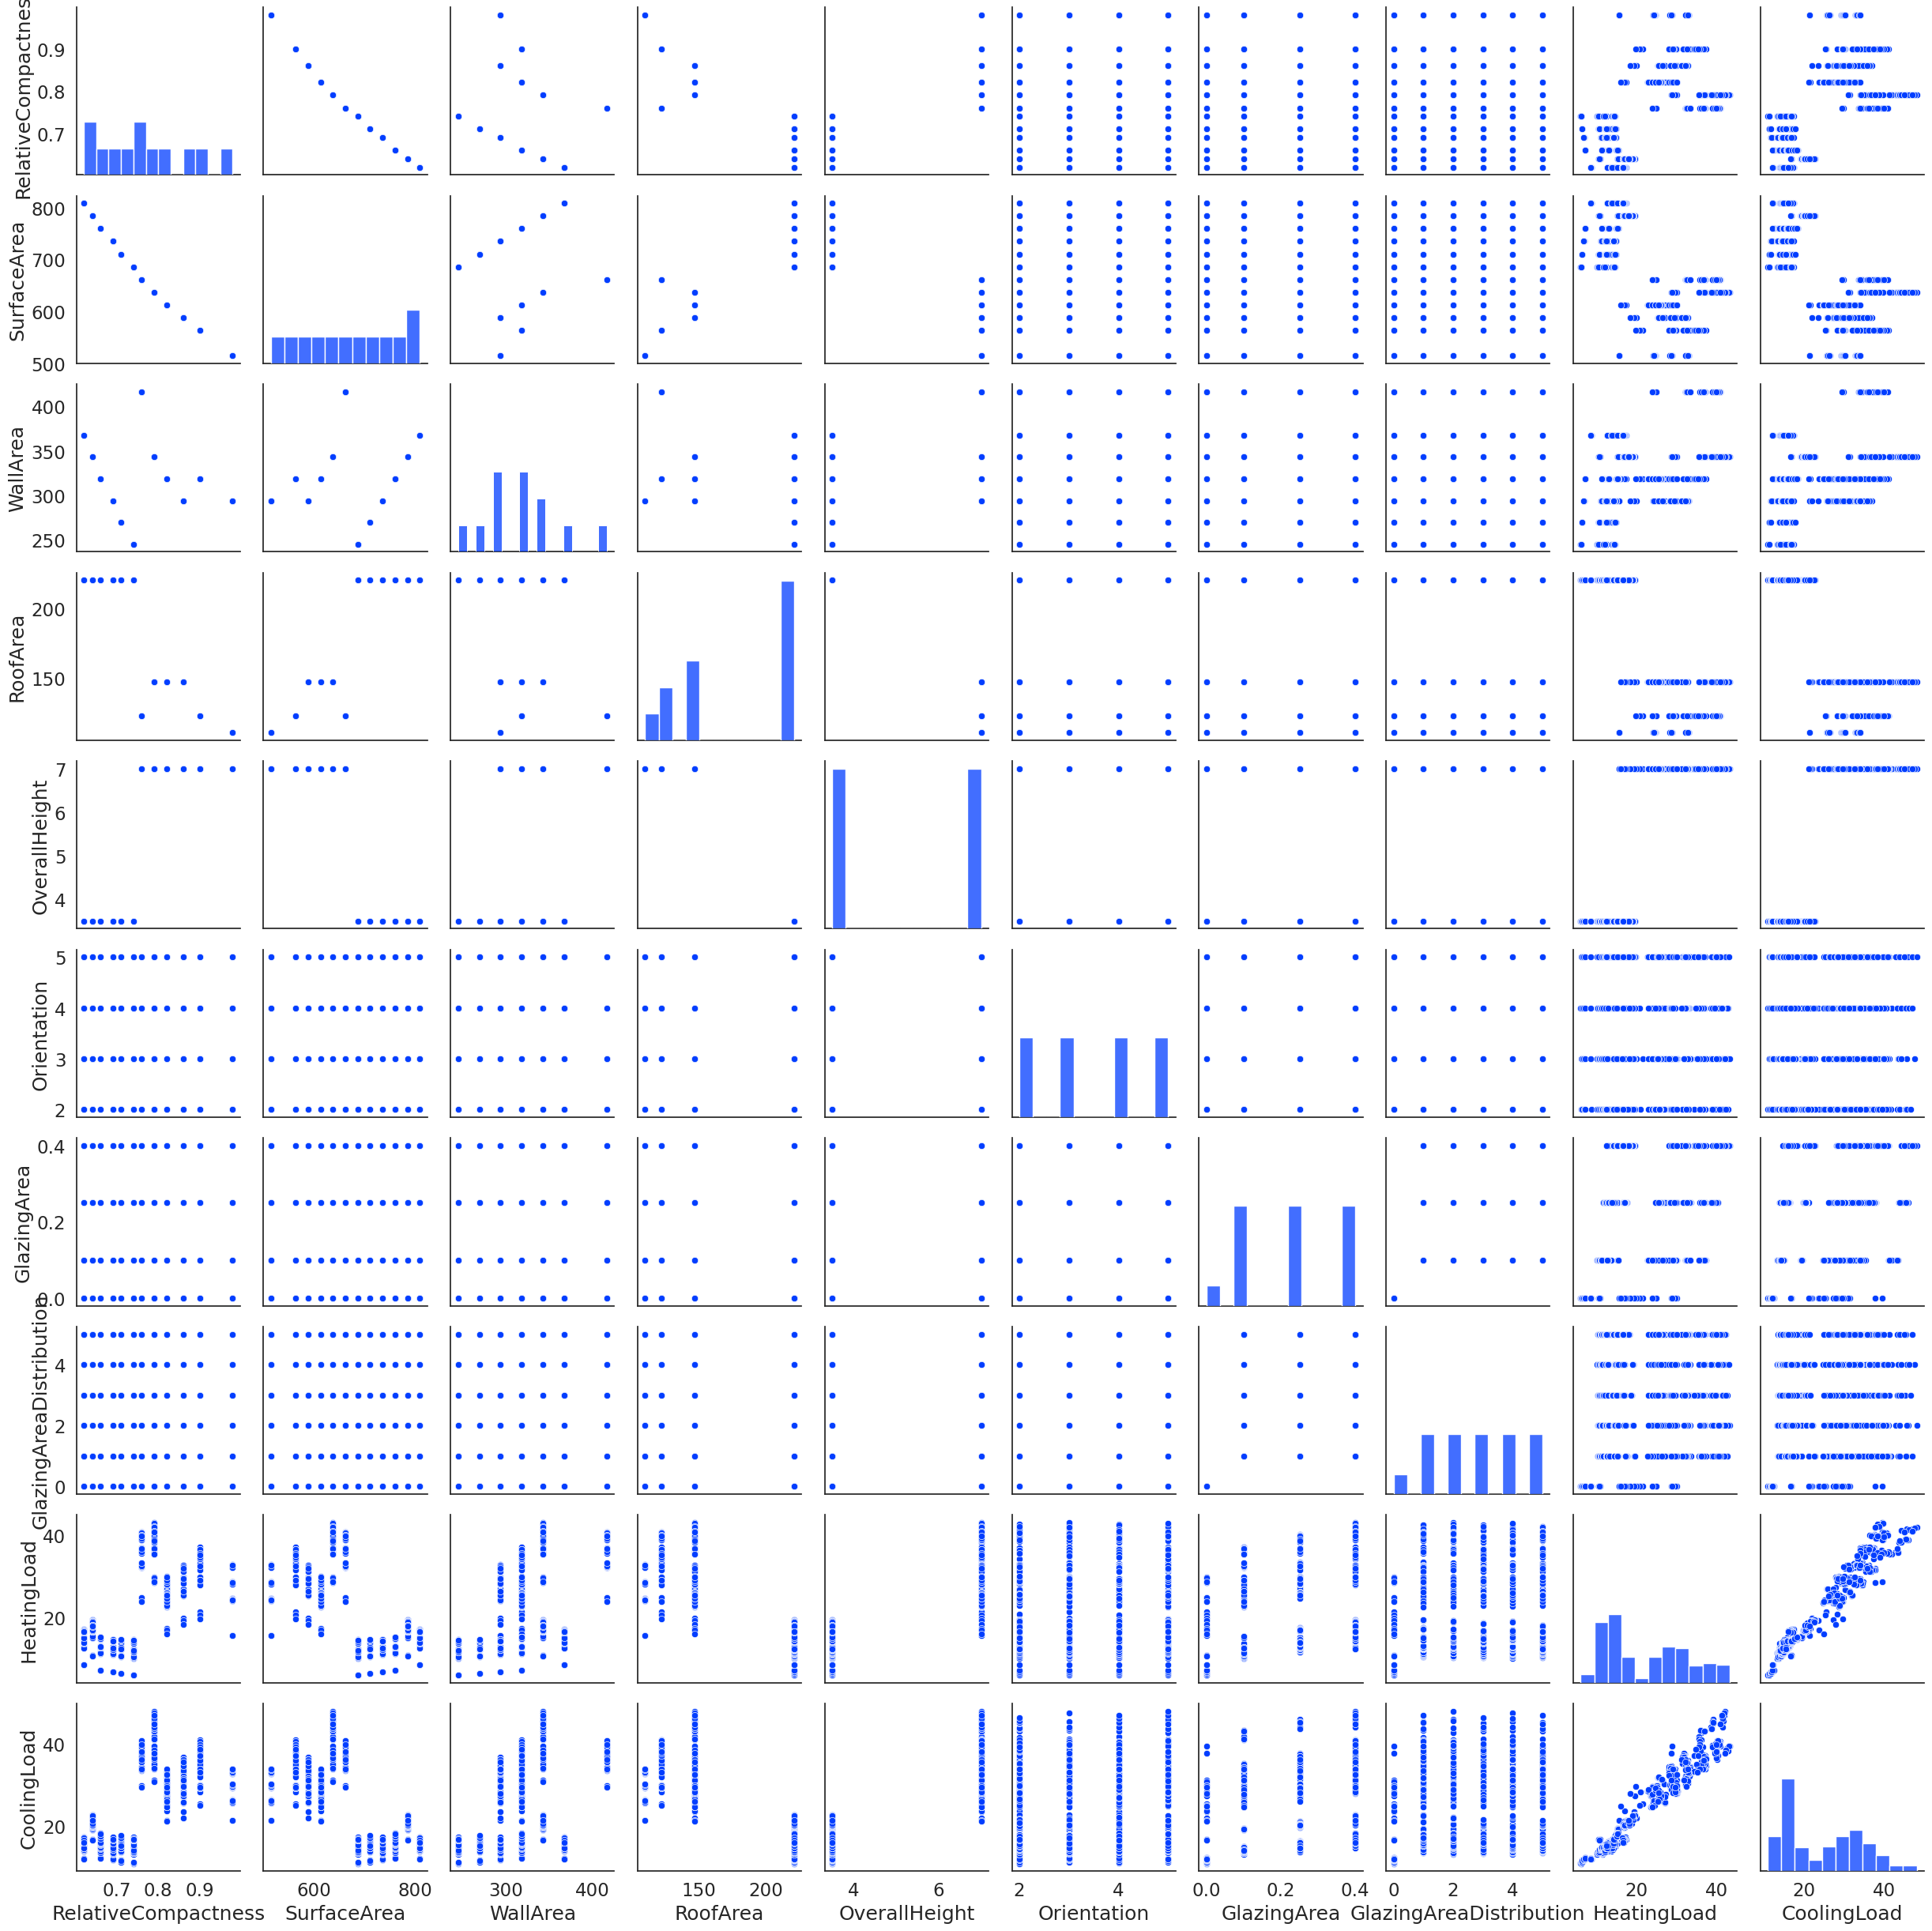

In [8]:
sns.pairplot(energy)

<Axes: >

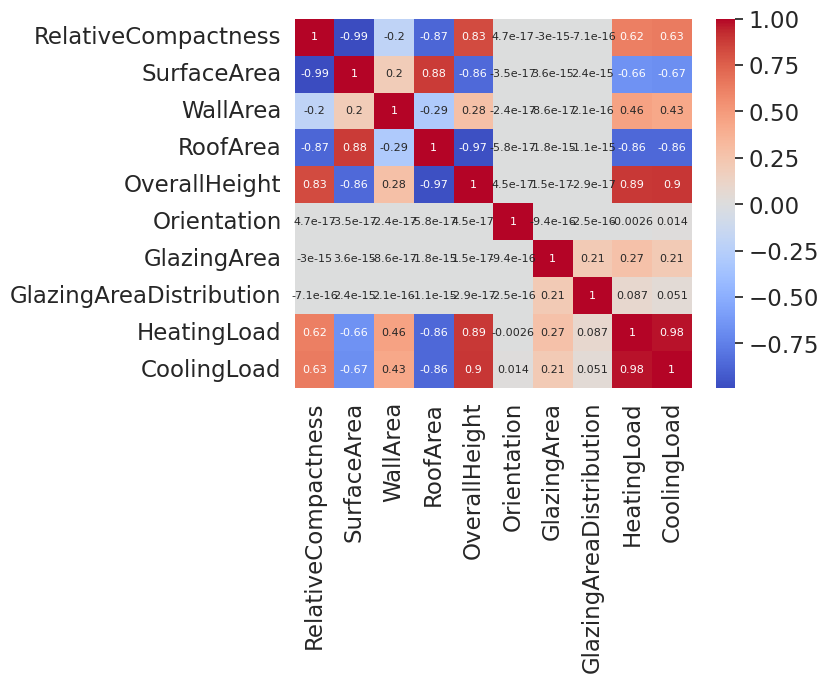

In [9]:
sns.heatmap(energy['RelativeCompactness SurfaceArea WallArea RoofArea OverallHeight Orientation GlazingArea GlazingAreaDistribution HeatingLoad CoolingLoad'.split()].corr(), cmap='coolwarm', annot=True, annot_kws={'size': 8})

In [10]:
X = energy['RelativeCompactness SurfaceArea WallArea RoofArea OverallHeight Orientation GlazingArea GlazingAreaDistribution HeatingLoad CoolingLoad'.split()]
#Y = energy['CoolingLoad']
Y = energy.CoolingLoad

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.35, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
model = LinearRegression()
model.fit(X_train_scaled, Y_train)
Y_pred = model.predict(X_test_scaled)
print("MSE:", mean_squared_error(Y_test, Y_pred))

MSE: 9.632900748959032e-29


In [13]:
model = RandomForestRegressor()
model.fit(X_train_scaled, Y_train)
Y_pred = model.predict(X_test_scaled)
print("MSE:", mean_squared_error(Y_test, Y_pred))

MSE: 0.007416345092936774


In [14]:
model = XGBRegressor()
model.fit(X_train_scaled, Y_train)
Y_pred = model.predict(X_test_scaled)
print("MSE:", mean_squared_error(Y_test, Y_pred))

MSE: 0.03619336949054653


In [15]:
mse_lr = np.array([])
mse_rf = np.array([])
mse_xb = np.array([])
#mse_nn = np.array([])

rnd = np.random.randint(1000, high=100000, size=50)
for i in np.arange(rnd.size):
    #print(f"Iter {i}")
    
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.35, random_state=rnd[i])

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # linear regression
    model = LinearRegression()
    model.fit(X_train_scaled, Y_train)
    Y_pred = model.predict(X_test_scaled)
    mse_lr = np.append(mse_lr, mean_squared_error(Y_test, Y_pred))

    # random forest
    model = RandomForestRegressor()
    model.fit(X_train_scaled, Y_train)
    Y_pred = model.predict(X_test_scaled)
    mse_rf = np.append(mse_rf, mean_squared_error(Y_test, Y_pred))

    # xgboost
    model = XGBRegressor()
    model.fit(X_train_scaled, Y_train)
    Y_pred = model.predict(X_test_scaled)
    mse_xb = np.append(mse_xb, mean_squared_error(Y_test, Y_pred))
    

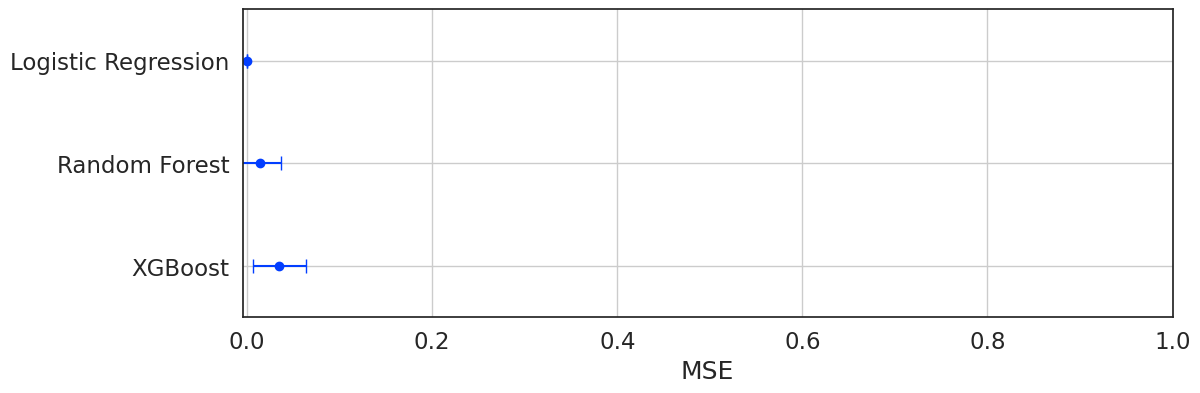

In [16]:
mse_mu = np.array([])
mse_err = np.array([])

for mse in [mse_lr, mse_rf, mse_xb]:
    mse_mu = np.append( mse_mu, np.mean(mse) )
    mse_err = np.append( mse_err, 0.5*(np.max(mse)-np.min(mse)) )

plt.figure(figsize=(12,4))
#plt.errorbar(mse_mu, ['Logistic Regression','Random Forest','XGBoost'], xerr=mse_err, ls='', marker='o', capsize=5)
plt.errorbar(np.flip(mse_mu), np.flip(['Logistic Regression','Random Forest','XGBoost']), xerr=np.flip(mse_err), ls='', marker='o', capsize=5)
plt.xlim(-0.005,1)
plt.ylim(-0.5,2.5)
plt.xlabel('MSE')
plt.grid()

